# 06 Sentiment Trends Over Time

This notebook visualizes monthly impact trends and adds a compact industry outlook for AI adoption.

Note: the later outlook charts are heuristic summaries inferred from article text, not causal forecasts.

In [1]:
import re

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

DATA_PATH = "040_sentiment.parquet"


## 1. Load data and extract month

In [2]:
df = pd.read_parquet(DATA_PATH).copy()
df = df[df["cluster"] != -1].copy()
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df = df.dropna(subset=["date"]).copy()
df["month"] = df["date"].dt.to_period("M").astype(str)

display(df[["date", "month", "industry", "organization", "technology", "impact"]].head())

,date,month,industry,organization,technology,impact
2,2024-09-22,2024-09,Software,1minAI,"GPT-4, Gemini Pro, Claude",1
6,2023-09-07,2023-09,Technology,Zoom,Generative AI,1
9,2025-12-15,2025-12,Technology,"OpenAI, Microsoft",AI,-1
10,2023-07-26,2023-07,Pharmaceuticals,Bullfrog AI Holdings Inc.,AI,1
11,2025-10-27,2025-10,Semiconductors,Qualcomm,AI chips,1


## 2. Overall monthly average impact

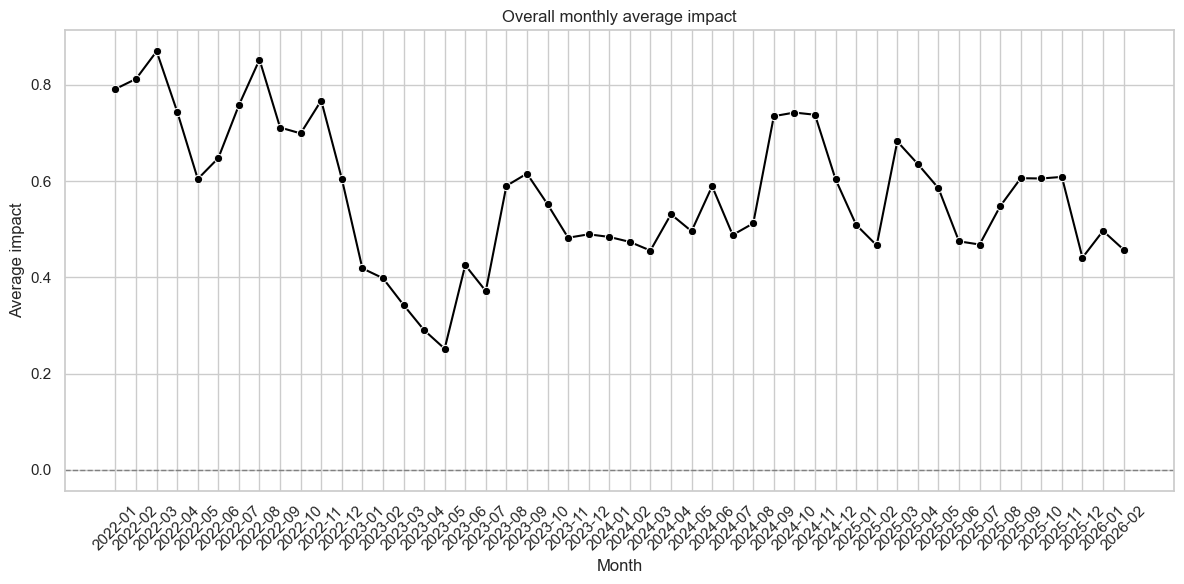

In [3]:
monthly_impact = df.groupby("month", as_index=False)["impact"].mean()

plt.figure(figsize=(12, 6))
sns.lineplot(data=monthly_impact, x="month", y="impact", marker="o", color="black")
plt.axhline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Overall monthly average impact")
plt.xlabel("Month")
plt.ylabel("Average impact")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 3. Cleaner monthly trend plots

In [4]:
def expand_category(frame, category):
    plot_df = frame[["month", category, "impact"]].dropna().copy()
    if category == "technology":
        plot_df[category] = plot_df[category].str.split(",")
        plot_df = plot_df.explode(category)
        plot_df[category] = plot_df[category].str.strip()
    plot_df = plot_df[plot_df[category].ne("")].copy()
    return plot_df

def plot_sentiment_trend(df, category, top_n=8, recent_months=18):
    plot_df = expand_category(df, category)
    month_order = sorted(plot_df["month"].unique())[-recent_months:]
    plot_df = plot_df[plot_df["month"].isin(month_order)].copy()

    top_values = plot_df[category].value_counts().head(top_n).index
    plot_df = plot_df[plot_df[category].isin(top_values)].copy()

    trend = plot_df.groupby(["month", category], as_index=False)["impact"].mean()
    trend["month"] = pd.Categorical(trend["month"], categories=month_order, ordered=True)

    plt.figure(figsize=(12, 6))
    sns.lineplot(data=trend, x="month", y="impact", hue=category, marker="o", linewidth=2)
    plt.axhline(0, color="gray", linestyle="--", linewidth=1)
    plt.title(f"Monthly average impact by {category} (top {top_n}, last {recent_months} months)")
    plt.xlabel("Month")
    plt.ylabel("Average impact")
    plt.xticks(rotation=45)
    plt.legend(title=category, bbox_to_anchor=(1.02, 1), loc="upper left", ncol=1)
    plt.tight_layout()
    plt.show()

    return trend

def plot_sentiment_heatmap(df, category, top_n=15, recent_months=18):
    plot_df = expand_category(df, category)
    month_order = sorted(plot_df["month"].unique())[-recent_months:]
    plot_df = plot_df[plot_df["month"].isin(month_order)].copy()

    top_values = plot_df[category].value_counts().head(top_n).index
    plot_df = plot_df[plot_df[category].isin(top_values)].copy()

    heatmap_data = (
        plot_df.groupby([category, "month"])["impact"]
        .mean()
        .unstack(fill_value=0)
        .reindex(columns=month_order)
    )

    plt.figure(figsize=(14, max(5, top_n * 0.45)))
    sns.heatmap(heatmap_data, cmap="vlag", center=0, linewidths=0.3)
    plt.title(f"Monthly average impact heatmap: {category} (top {top_n})")
    plt.xlabel("Month")
    plt.ylabel("")
    plt.tight_layout()
    plt.show()


## 4. Topic, industry, and technology trends

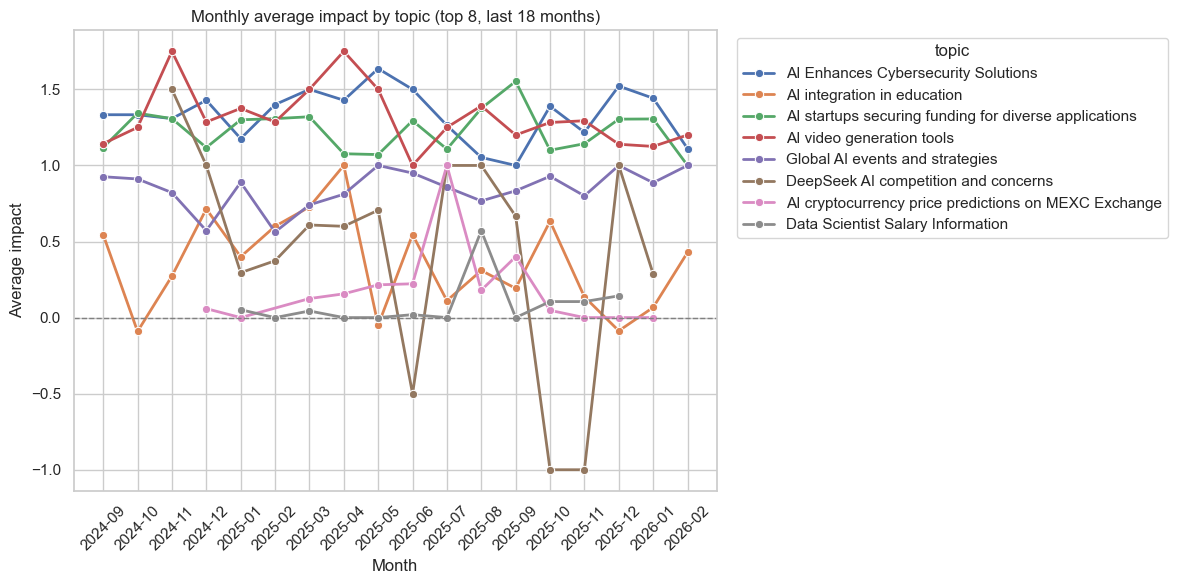

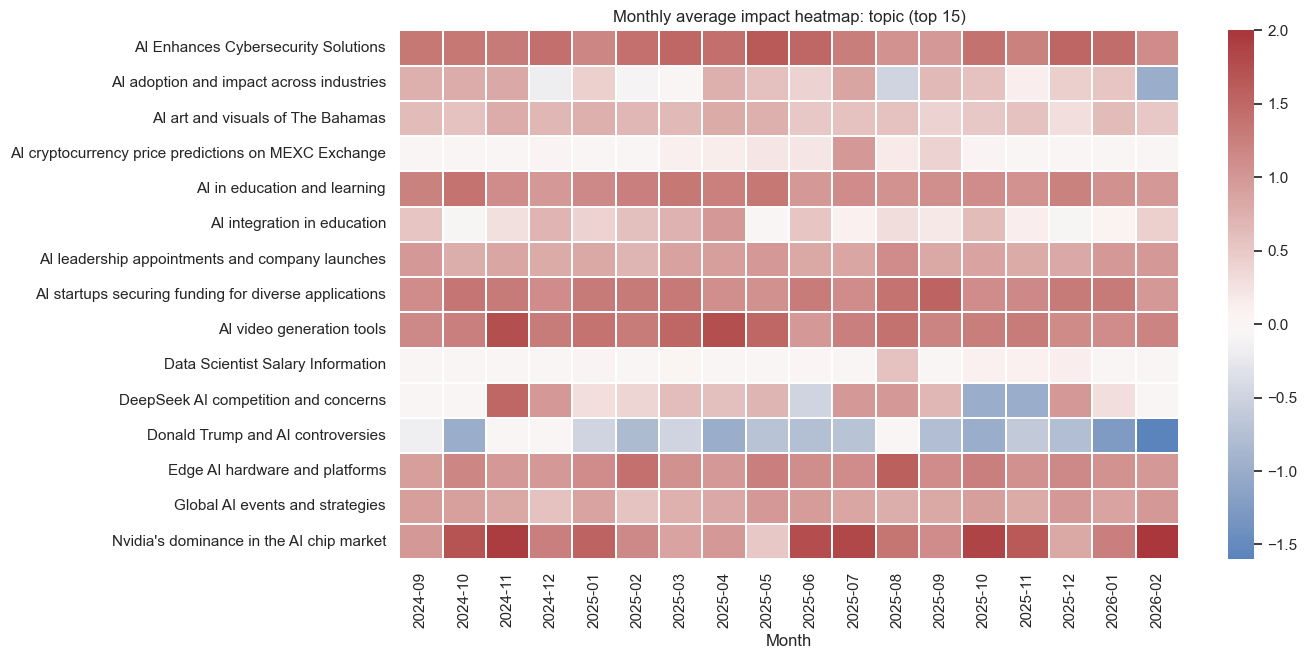

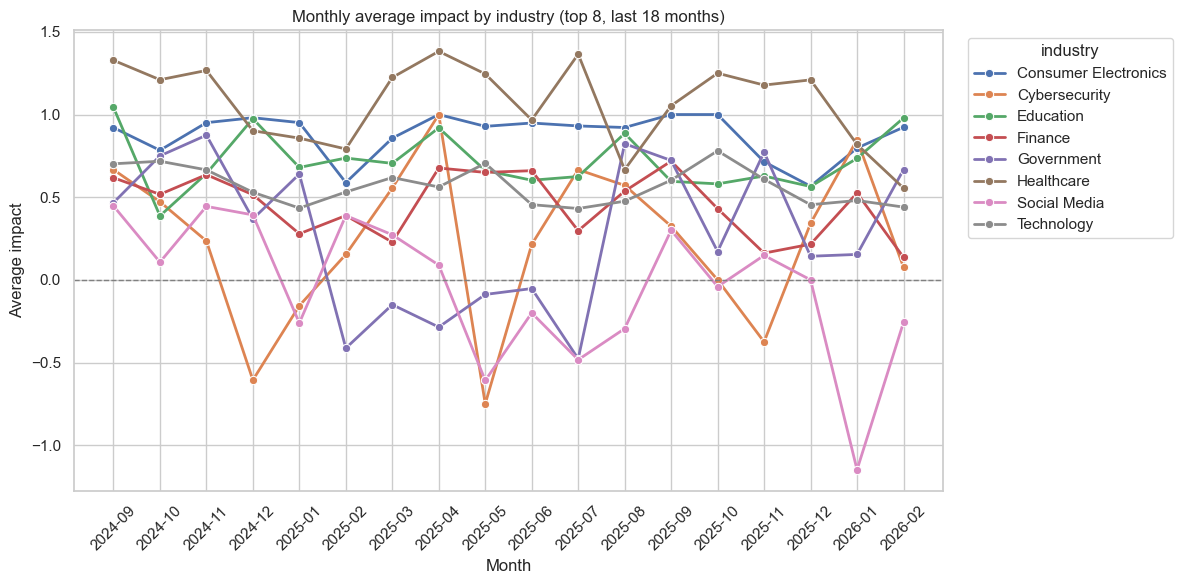

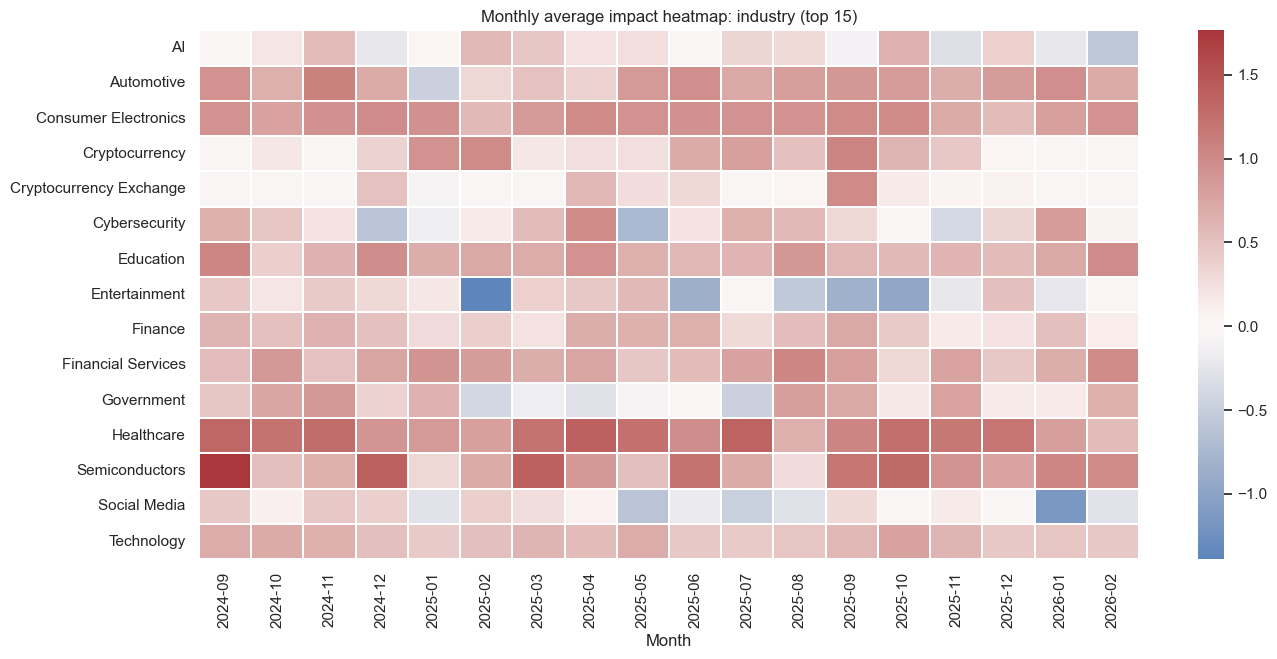

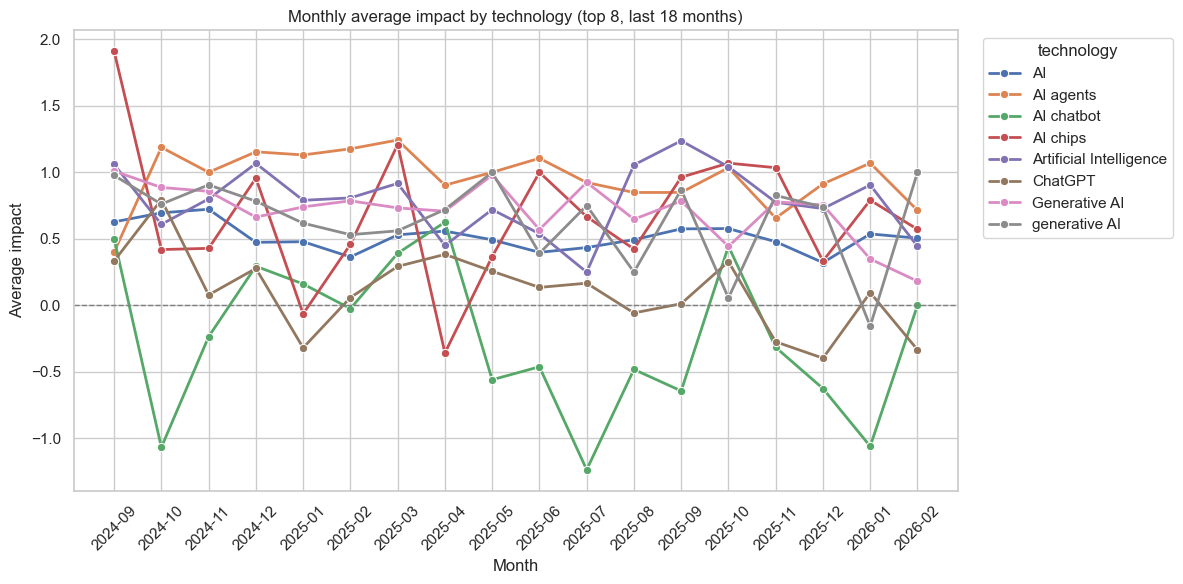

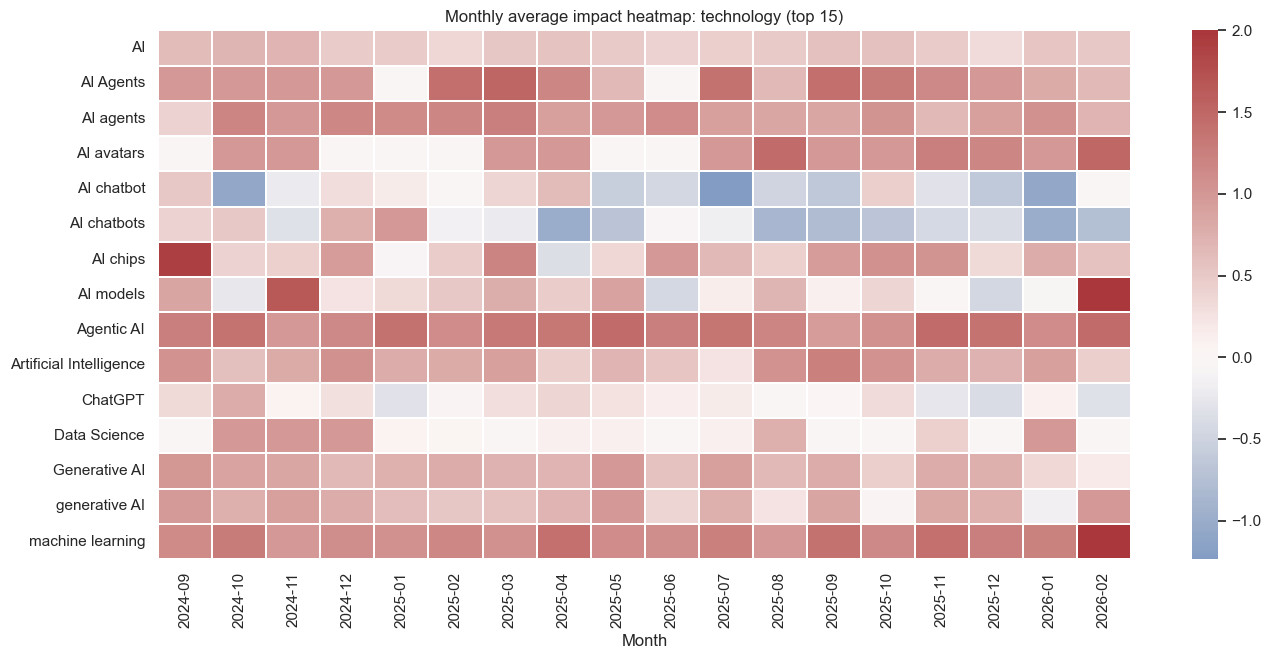

In [5]:
topic_trend = plot_sentiment_trend(df, "topic")
plot_sentiment_heatmap(df, "topic")

industry_trend = plot_sentiment_trend(df, "industry")
plot_sentiment_heatmap(df, "industry")

technology_trend = plot_sentiment_trend(df, "technology")
plot_sentiment_heatmap(df, "technology")

## 5. Industries most likely to be impacted by AI

Here I use article volume plus average absolute impact as a simple proxy for likely multi-year exposure.

,industry,article_count,avg_impact,avg_abs_impact,positive_share,negative_share
1578,Cybersecurity,1197,0.155388,1.426901,0.547201,0.162072
5273,Semiconductor,486,1.006173,1.409465,0.730453,0.228395
765,Biotechnology,429,1.347319,1.389277,0.801865,0.060606
4071,Military,203,-0.458128,1.364532,0.389163,0.266010
4569,Pharmaceuticals,217,1.327189,1.345622,0.866359,0.013825
1798,Defense,344,0.555233,1.328488,0.654070,0.177326
3051,Healthcare,3154,1.162334,1.326569,0.716550,0.083069
5289,Semiconductors,946,0.952431,1.320296,0.701903,0.230444
323,Agriculture,334,1.245509,1.257485,0.721557,0.023952
3781,Manufacturing,206,1.150485,1.237864,0.733010,0.067961


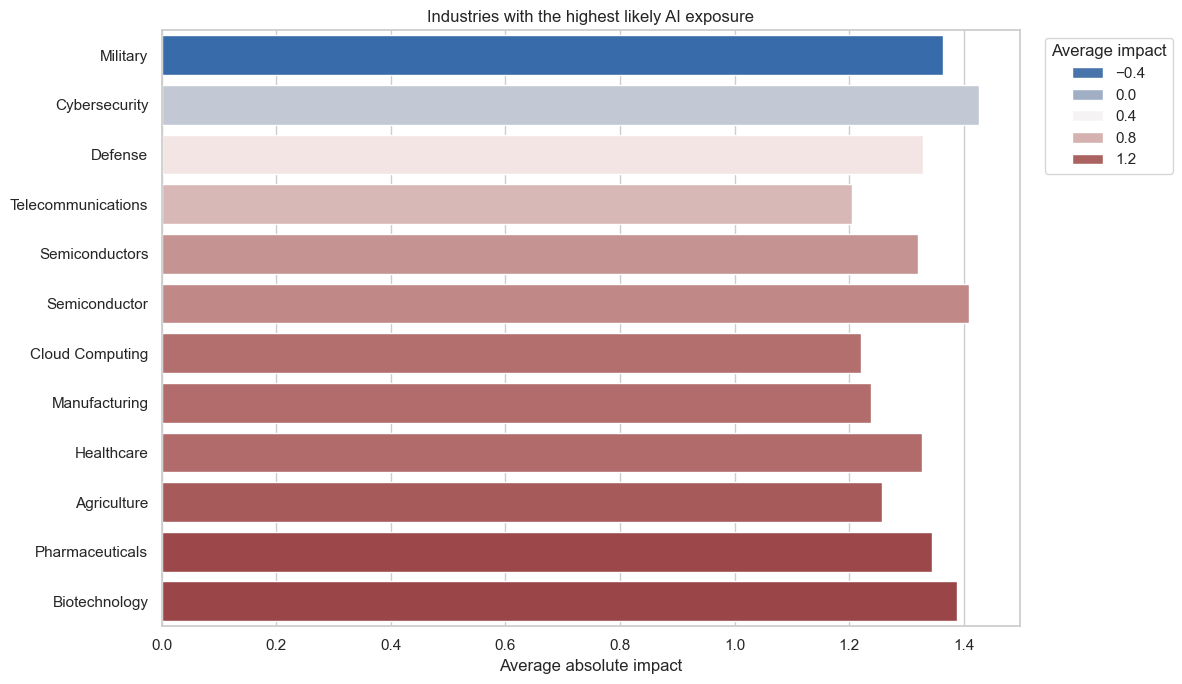

In [6]:
industry_outlook = (
    df.groupby("industry", as_index=False)
    .agg(
        article_count=("title", "size"),
        avg_impact=("impact", "mean"),
        avg_abs_impact=("impact", lambda s: s.abs().mean()),
        positive_share=("sentiment", lambda s: (s == "positive").mean()),
        negative_share=("sentiment", lambda s: (s == "negative").mean()),
    )
    .query("article_count >= 200")
    .sort_values(["avg_abs_impact", "article_count"], ascending=[False, False])
)

display(industry_outlook.head(15))

industry_plot = industry_outlook.head(12).sort_values("avg_impact")
plt.figure(figsize=(12, 7))
sns.barplot(data=industry_plot, y="industry", x="avg_abs_impact", hue="avg_impact", palette="vlag")
plt.title("Industries with the highest likely AI exposure")
plt.xlabel("Average absolute impact")
plt.ylabel("")
plt.legend(title="Average impact", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 6. Companies inside the most exposed industries

,industry,organization,article_count,avg_impact,avg_abs_impact
0,Biotechnology,Google DeepMind,28,1.892857,1.892857
1,Biotechnology,DeepMind,16,1.875000,1.875000
2,Biotechnology,Researchers,17,1.705882,1.705882
3,Cybersecurity,Scammers,27,-2.000000,2.000000
4,Cybersecurity,Cybercriminals,19,-2.000000,2.000000
5,Cybersecurity,Britain's National Cyber Security Centre,8,-2.000000,2.000000
6,Defense,Philippine military,12,-1.833333,1.833333
7,Defense,Military,12,0.666667,1.666667
8,Defense,Indian Army,10,1.500000,1.500000
9,Healthcare,Brainomix,9,1.888889,1.888889


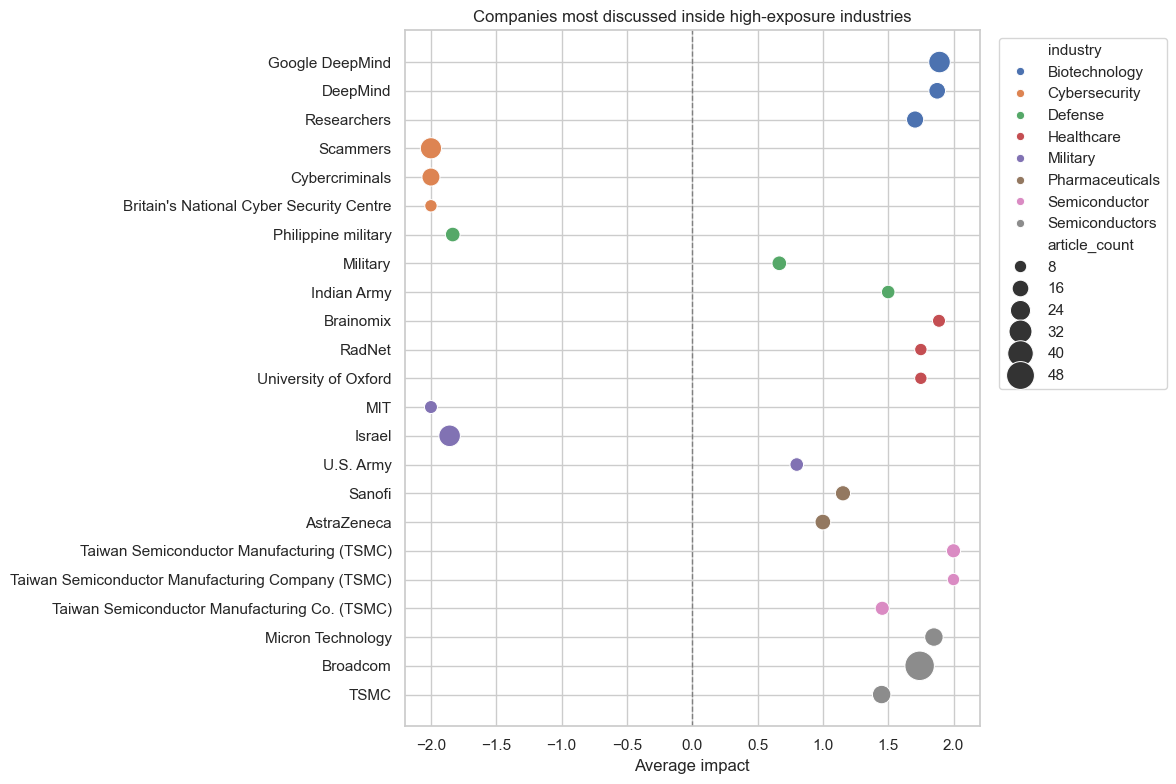

In [7]:
top_industries = industry_outlook.head(8)["industry"]

org_df = df[df["industry"].isin(top_industries)][["industry", "organization", "impact", "title"]].dropna().copy()
org_df["organization"] = org_df["organization"].str.split(",")
org_df = org_df.explode("organization")
org_df["organization"] = org_df["organization"].str.strip()
org_df = org_df[org_df["organization"].ne("")].copy()

company_outlook = (
    org_df.groupby(["industry", "organization"], as_index=False)
    .agg(
        article_count=("title", "size"),
        avg_impact=("impact", "mean"),
        avg_abs_impact=("impact", lambda s: s.abs().mean()),
    )
    .query("article_count >= 8")
    .sort_values(["industry", "avg_abs_impact", "article_count"], ascending=[True, False, False])
)

top_companies = company_outlook.groupby("industry").head(3).reset_index(drop=True)
display(top_companies)

plt.figure(figsize=(12, 8))
sns.scatterplot(
    data=top_companies,
    x="avg_impact",
    y="organization",
    size="article_count",
    hue="industry",
    sizes=(80, 450),
)
plt.axvline(0, color="gray", linestyle="--", linewidth=1)
plt.title("Companies most discussed inside high-exposure industries")
plt.xlabel("Average impact")
plt.ylabel("")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

## 7. By what means will AI affect them?

The chart below uses keyword heuristics to infer common AI mechanisms from article text.

,industry,mechanism,article_count,avg_impact
5,Biotechnology,workflow redesign,139,1.467626
2,Biotechnology,automation,111,1.504505
0,Biotechnology,analytics and prediction,82,1.390244
6,Cybersecurity,analytics and prediction,360,0.811111
11,Cybersecurity,workflow redesign,347,0.847262
8,Cybersecurity,automation,243,0.827160
17,Defense,workflow redesign,117,1.034188
14,Defense,automation,72,0.708333
13,Defense,augmentation,43,1.023256
18,Healthcare,analytics and prediction,1437,1.415449


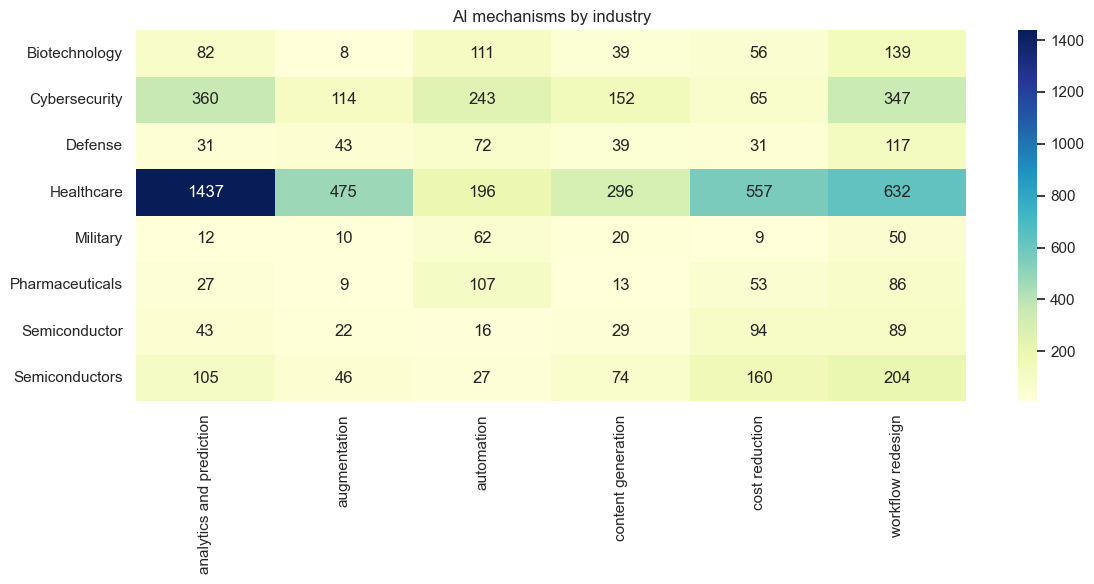

In [8]:
df["text"] = (
    df["title"].fillna("") + " " + df["summary"].fillna("") + " " + df["topic"].fillna("") + " " + df["technology"].fillna("")
).str.lower()

mechanism_map = {
    "automation": ["automation", "automate", "autonomous", "robot", "agentic", "ai agent", "agents"],
    "augmentation": ["copilot", "assistant", "assist", "augmentation", "support"],
    "workflow redesign": ["workflow", "orchestration", "integration", "platform", "operations", "process"],
    "cost reduction": ["cost", "efficiency", "efficient", "reduce costs", "savings", "margin"],
    "content generation": ["generate", "generation", "image", "video", "writing", "content"],
    "analytics and prediction": ["analytics", "forecast", "prediction", "detect", "diagnosis", "insight", "recommendation"],
}

def build_signal_frame(df, mapping, signal_name):
    frames = []
    for label, keywords in mapping.items():
        pattern = "|".join(re.escape(keyword) for keyword in keywords)
        temp = df[df["text"].str.contains(pattern, regex=True, na=False)][["title", "industry", "impact"]].copy()
        temp[signal_name] = label
        frames.append(temp)
    return pd.concat(frames, ignore_index=True).drop_duplicates(["title", signal_name])

mechanism_hits = build_signal_frame(df[df["industry"].isin(top_industries)], mechanism_map, "mechanism")

mechanism_summary = (
    mechanism_hits.groupby(["industry", "mechanism"], as_index=False)
    .agg(article_count=("title", "size"), avg_impact=("impact", "mean"))
)

display(mechanism_summary.sort_values(["industry", "article_count"], ascending=[True, False]).groupby("industry").head(3))

mechanism_heatmap = mechanism_summary.pivot(index="industry", columns="mechanism", values="article_count").fillna(0)
plt.figure(figsize=(12, 6))
sns.heatmap(mechanism_heatmap, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("AI mechanisms by industry")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

## 8. What helps adoption succeed or fail?

These signals are again inferred from article text, so treat them as directional evidence.

,signal_type,factor,article_count,avg_impact
0,risk,infrastructure cost,5775,0.955325
1,risk,regulation and legal risk,12942,-0.037784
2,risk,trust and quality issues,8085,-0.069759
3,risk,workforce disruption,1701,-0.096414
6,success,productivity gains,13227,1.005065
5,success,decision support,10978,0.913190
7,success,workflow integration,19551,0.822822
4,success,capability expansion,22711,0.424728


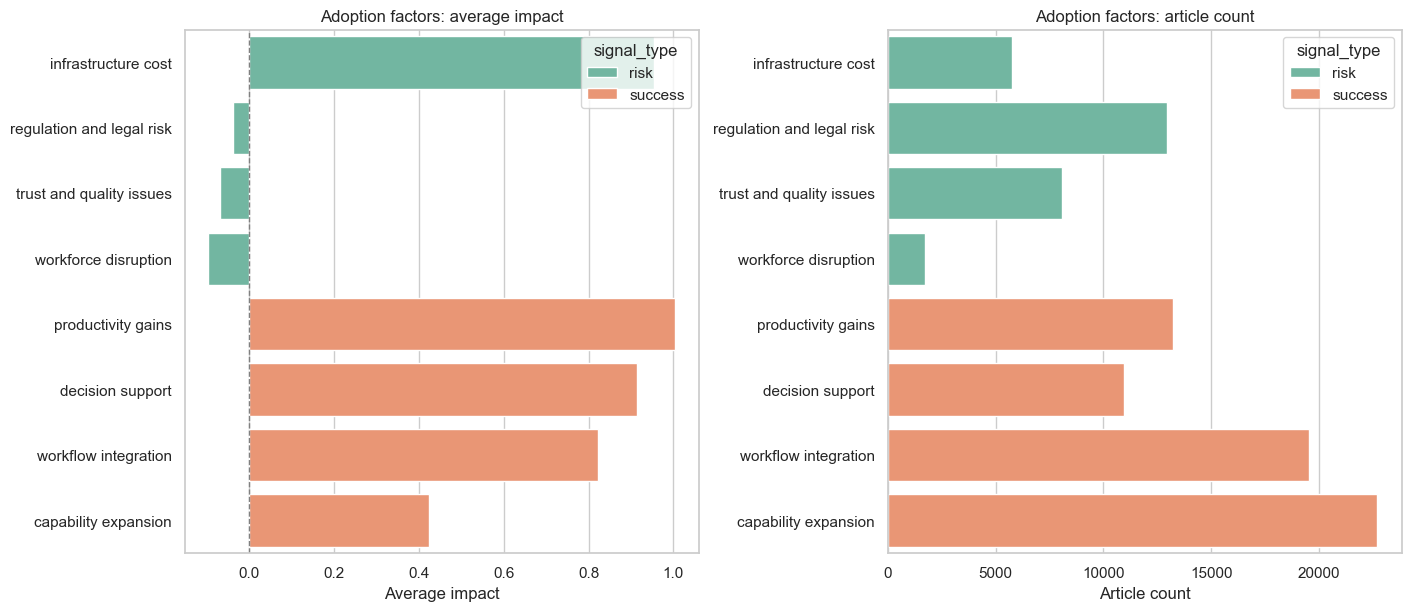

In [9]:
success_map = {
    "workflow integration": ["integration", "embedded", "deployed", "deployment", "platform", "workflow"],
    "productivity gains": ["productivity", "efficiency", "faster", "speed", "save time", "cost"],
    "decision support": ["copilot", "assistant", "recommendation", "insight", "analysis"],
    "capability expansion": ["generate", "generation", "multimodal", "agent", "automation"],
}

risk_map = {
    "trust and quality issues": ["hallucination", "error", "accuracy", "bias", "unreliable", "fake", "deepfake"],
    "regulation and legal risk": ["regulation", "regulatory", "lawsuit", "copyright", "compliance", "privacy"],
    "workforce disruption": ["layoff", "job loss", "replace workers", "replacement", "displace"],
    "infrastructure cost": ["chip shortage", "compute", "gpu", "energy", "costly", "expensive"],
}

success_hits = build_signal_frame(df, success_map, "factor")
success_hits["signal_type"] = "success"

risk_hits = build_signal_frame(df, risk_map, "factor")
risk_hits["signal_type"] = "risk"

factor_summary = (
    pd.concat([success_hits, risk_hits], ignore_index=True)
    .groupby(["signal_type", "factor"], as_index=False)
    .agg(article_count=("title", "size"), avg_impact=("impact", "mean"))
    .sort_values(["signal_type", "avg_impact"], ascending=[True, False])
)

display(factor_summary)

fig, axes = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)
sns.barplot(data=factor_summary, y="factor", x="avg_impact", hue="signal_type", palette="Set2", ax=axes[0])
axes[0].axvline(0, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Adoption factors: average impact")
axes[0].set_xlabel("Average impact")
axes[0].set_ylabel("")

sns.barplot(data=factor_summary, y="factor", x="article_count", hue="signal_type", palette="Set2", ax=axes[1])
axes[1].set_title("Adoption factors: article count")
axes[1].set_xlabel("Article count")
axes[1].set_ylabel("")

plt.show()

## 9. Compact interpretation

In [10]:
top_positive_industry = industry_outlook.sort_values("avg_impact", ascending=False).iloc[0]
top_negative_industry = industry_outlook.sort_values("avg_impact", ascending=True).iloc[0]
top_mechanism = mechanism_summary.groupby("mechanism", as_index=False)["article_count"].sum().sort_values("article_count", ascending=False).iloc[0]
top_success = factor_summary.query('signal_type == "success"').sort_values("avg_impact", ascending=False).iloc[0]
top_risk = factor_summary.query('signal_type == "risk"').sort_values("avg_impact", ascending=True).iloc[0]

print(f"Most positively exposed major industry: {top_positive_industry['industry']} ({top_positive_industry['avg_impact']:.2f}).")
print(f"Most negatively exposed major industry: {top_negative_industry['industry']} ({top_negative_industry['avg_impact']:.2f}).")
print(f"Most common AI mechanism in the top industries: {top_mechanism['mechanism']} ({int(top_mechanism['article_count'])} matched articles).")
print(f"Strongest success signal: {top_success['factor']} ({top_success['avg_impact']:.2f}).")
print(f"Strongest failure signal: {top_risk['factor']} ({top_risk['avg_impact']:.2f}).")

Most positively exposed major industry: Biotechnology (1.35).
Most negatively exposed major industry: Politics (-0.77).
Most common AI mechanism in the top industries: analytics and prediction (2097 matched articles).
Strongest success signal: productivity gains (1.01).
Strongest failure signal: workforce disruption (-0.10).
